<a href="https://colab.research.google.com/github/deshmukhvaishnavi04/celebal-internship/blob/main/week5_vaishnavi_deshmukh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Text Generation using Vanilla RNN, LSTM and GRU

###Import Libraries

In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

import numpy as np

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0




###Load Text Corpus

In [31]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
"""

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



###Tokenization & Sequence Creation

In [32]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(sequence) for sequence in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Vocabulary Size: 37
Input Shape: (35, 7)
Output Shape: (35,)


###Vanilla RNN Model

In [33]:
rnn_model = Sequential([

    Embedding(total_words, 64, input_length=max_len-1),

    SimpleRNN(128),

    Dense(total_words, activation="softmax")

])

rnn_model.build(input_shape=(None, max_len-1))
rnn_model.summary()

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 7, 64)          │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,845 (124.39 KB)

 Trainable params: 31,845 (124.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.0286 - loss: 3.6136
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1429 - loss: 3.5455
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2857 - loss: 3.4985
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3429 - loss: 3.4538
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4571 - loss: 3.4111
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4000 - loss: 3.3641
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4000 - loss: 3.3157
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3143 - loss: 3.2675
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2857 - loss: 3.2145
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2571 - loss: 3.1725
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2286 - loss: 3.1229
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2571 - lo

###LSTM Model

In [34]:
lstm_model = Sequential([

    Embedding(total_words, 64, input_length=max_len-1),

    LSTM(128),

    Dense(total_words, activation="softmax")

])

lstm_model.build(input_shape=(None, max_len-1))
lstm_model.summary()


lstm_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

lstm_history = lstm_model.fit(

    X,

    y,

    epochs=200,

    verbose=1

)

print("LSTM Training Completed")

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 7, 64)          │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,957 (413.89 KB)

 Trainable params: 105,957 (413.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.0286 - loss: 3.6133
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0571 - loss: 3.6050 
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1143 - loss: 3.5995
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.0571 - loss: 3.5940
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0571 - loss: 3.5881 
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0857 - loss: 3.5825
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0857 - loss: 3.5756
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0857 - loss: 3.5680
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0857 - loss: 3.5584
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0857 - loss: 3.5472
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.0857 - loss: 3.5338
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0857 

###GRU Model

In [35]:
gru_model = Sequential([

    Embedding(total_words,64,input_length=max_len-1),

    GRU(128),

    Dense(total_words,activation="softmax")

])

gru_model.build(input_shape=(None, max_len-1))
gru_model.summary()

gru_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

gru_history = gru_model.fit(

    X,

    y,

    epochs=200,

    verbose=1

)

print("GRU Training Completed")

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ (None, 7, 64)          │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,637 (318.89 KB)

 Trainable params: 81,637 (318.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.0571 - loss: 3.6071
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1143 - loss: 3.5933
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1143 - loss: 3.5830
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1143 - loss: 3.5728
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1143 - loss: 3.5626
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0857 - loss: 3.5523
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0857 - loss: 3.5408
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1429 - loss: 3.5285
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1429 - loss: 3.5139
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1429 - loss: 3.4985
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0857 - loss: 3.4791
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0857 - lo

###Compare Training Loss

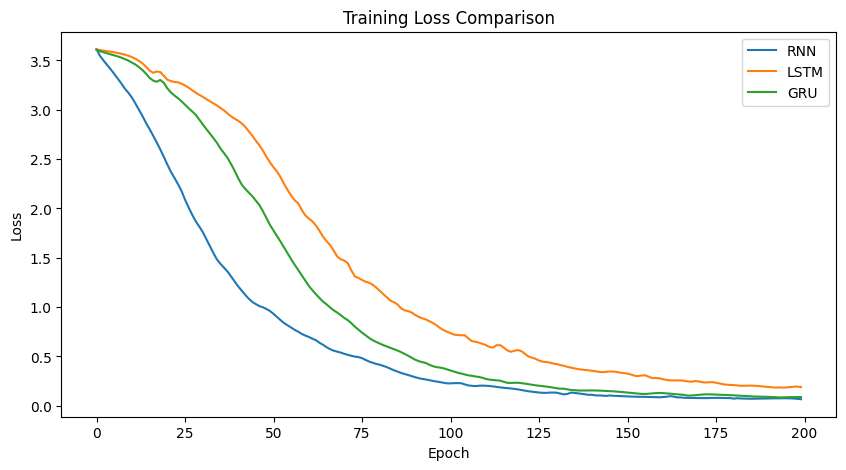

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history["loss"],
    label="RNN"
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM"
)

plt.plot(
    gru_history.history["loss"],
    label="GRU"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.show()

###Text Generation Function

In [37]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding="pre"
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word

                break

        seed_text += " " + output_word

    return seed_text

###Generate Text Samples

In [38]:
print("RNN :", generate_text(rnn_model, "artificial intelligence", 10))
print("LSTM:", generate_text(lstm_model, "artificial intelligence", 10))
print("GRU :", generate_text(gru_model, "artificial intelligence", 10))

RNN : artificial intelligence is generation models predict the next word gru for sequential
LSTM: artificial intelligence generation models predict the next word word word data data
GRU : artificial intelligence models can generate meaningful sentences sentences sentences sentences sentences data


Generated text from the LSTM and GRU models is generally more meaningful and coherent than the Vanilla RNN because they are better at learning long-term dependencies.

###Model Evaluation

In [39]:
rnn_loss, rnn_acc = rnn_model.evaluate(X, y, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X, y, verbose=0)
gru_loss, gru_acc = gru_model.evaluate(X, y, verbose=0)

print("RNN Accuracy :", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy :", gru_acc)

RNN Accuracy : 0.9714285731315613
LSTM Accuracy: 0.9714285731315613
GRU Accuracy : 0.9714285731315613


###Model Comparison Table





In [40]:
comparison = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Accuracy": [rnn_acc, lstm_acc, gru_acc],
    "Loss": [rnn_loss, lstm_loss, gru_loss]
})

comparison

,Model,Accuracy,Loss
0,Vanilla RNN,0.971429,0.065976
1,LSTM,0.971429,0.181415
2,GRU,0.971429,0.088249


###Accuracy Comparison Graph

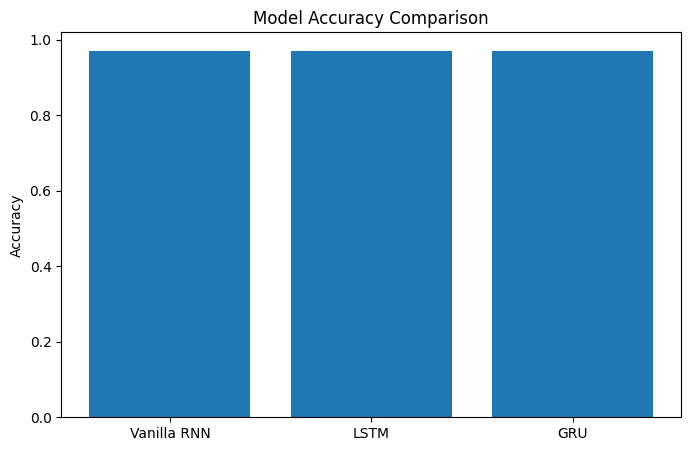

In [41]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

###Conclusion

This project successfully implemented text generation using Vanilla RNN, LSTM, and GRU models. The Vanilla RNN learned basic sequential patterns but struggled with long-term dependencies. LSTM generated more coherent and context-aware text due to its memory gates, while GRU achieved comparable performance with a simpler and faster architecture. The comparison shows that gated recurrent networks (LSTM and GRU) are more effective than Vanilla RNN for text generation tasks.